In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_decision_boundaries(
    X,
    y,
    model=None,
    predict_func=None,
    grid_resolution=200,
    padding=1.0,
    ax=None
):
    """
    Flexible decision boundary plotter (fast + model-agnostic)

    Parameters
    ----------
    X : array-like (n_samples, n_features)
    y : array-like (n_samples,)
    model : fitted model (optional)
    predict_func : callable(X) -> labels (optional, overrides model)
    grid_resolution : int (controls speed vs smoothness)
    padding : float (plot margin)
    ax : matplotlib axis
    """

    X = np.asarray(X)
    y = np.asarray(y).flatten()

    if X.shape[1] > 2:
        X = X[:, :2]

    if ax is None:
        fig, ax = plt.subplots()

    # ---- Grid (FAST version)
    x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_resolution),
        np.linspace(y_min, y_max, grid_resolution)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # ---- Prediction handler
    if predict_func is not None:
        Z = predict_func(grid)

    elif model is not None:
        try:
            Z = model.predict(grid)
        except:
            # torch / keras fallback
            Z = model(grid)

    else:
        raise ValueError("Provide either model or predict_func")

    Z = np.array(Z).reshape(xx.shape)

    # ---- Plot
    ax.contourf(xx, yy, Z, alpha=0.35)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

    return ax

/opt/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


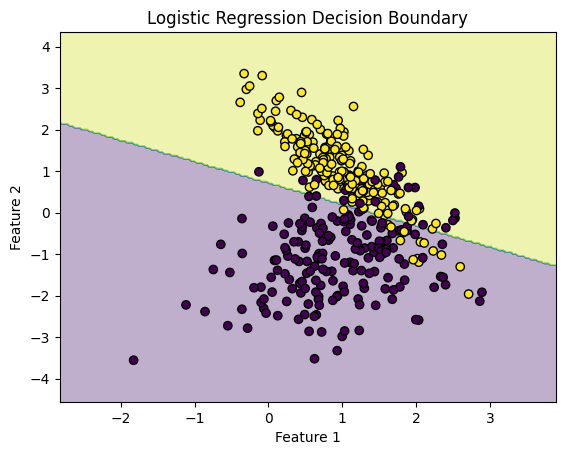

In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# ---- Generate data
X, y = make_classification(
    n_samples=400,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# ---- Fit model
model = LogisticRegression()
model.fit(X, y)

# ---- Plot
plot_decision_boundaries(X, y, model=model)
plt.title("Logistic Regression Decision Boundary")
plt.show()

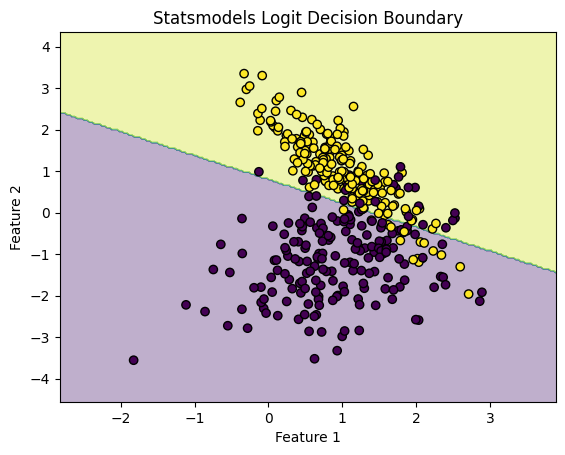

In [3]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---- Add intercept
X_sm = sm.add_constant(X)

# ---- Fit logit model
res = sm.Logit(y, X_sm).fit(disp=False)

# ---- Plot using custom predictor
plot_decision_boundaries(
    X, y,
    predict_func=lambda z: (res.predict(sm.add_constant(z)) > 0.5).astype(int)
)

plt.title("Statsmodels Logit Decision Boundary")
plt.show()

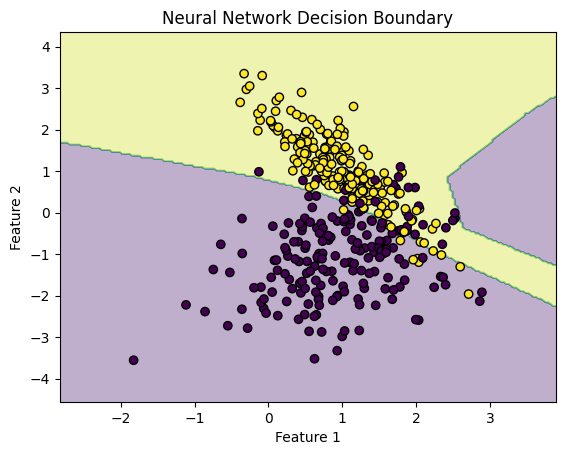

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---- Simple NN
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU(),
            nn.Linear(10, 2)
        )

    def forward(self, x):
        return self.net(x)

# ---- Train model
model_torch = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.01)

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

for _ in range(200):
    optimizer.zero_grad()
    loss = criterion(model_torch(X_t), y_t)
    loss.backward()
    optimizer.step()

# ---- Plot
plot_decision_boundaries(
    X, y,
    predict_func=lambda z: model_torch(torch.tensor(z, dtype=torch.float32))
                          .argmax(1).detach().numpy()
)

plt.title("Neural Network Decision Boundary")
plt.show()

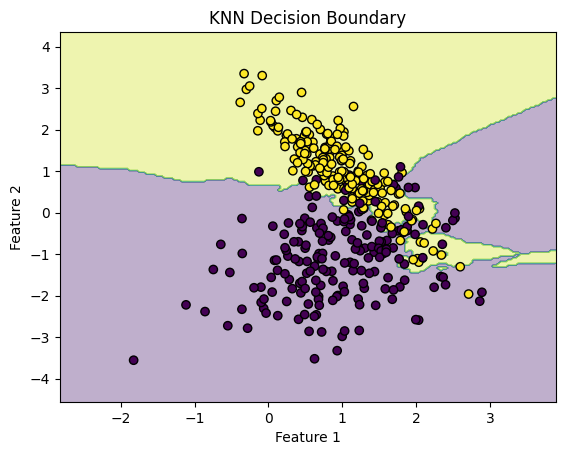

In [5]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X, y)

plot_decision_boundaries(X, y, model=model)
plt.title("KNN Decision Boundary")
plt.show()